In [7]:
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime, timedelta
import os

# ====================== Data Loading Functions ======================
def load_stablecoin_prices(csv_path="stablecoin_prices_2025_nov.csv", days=30):
    """
    Prioritize reading from local CSV. Only fetch from CoinGecko if the file doesn't exist or force update is needed.
    """
    if os.path.exists(csv_path):
        print(f"✅ Reading data from local CSV: {csv_path}")
        prices = pd.read_csv(csv_path, index_col='timestamp', parse_dates=True)
        print(f"Data shape: {prices.shape} | Time range: {prices.index[0]} → {prices.index[-1]}")
        return prices
    else:
        print("⚠️ Local CSV does not exist, starting to fetch data from CoinGecko...")
        prices = fetch_all_stablecoins(days=days)
        prices.to_csv(csv_path)
        print(f"✅ Data has been saved to {csv_path}")
        return prices

In [8]:
def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Input: Price DataFrame with stablecoins as columns
    Output: Log returns DataFrame
    """
    log_returns = np.log(prices / prices.shift(1)).dropna()
    return log_returns


prices = load_stablecoin_prices(
    csv_path="stablecoin_prices_2025_nov.csv",  # You can change the filename here
    days=30
)

log_ret = compute_log_returns(prices)
print(log_ret.describe())

✅ Reading data from local CSV: stablecoin_prices_2025_nov.csv
Data shape: (553, 5) | Time range: 2025-09-01 04:00:00 → 2025-12-02 04:00:00
             usde          usdt          usdc           dai        frax
count  552.000000  5.520000e+02  5.520000e+02  5.520000e+02  552.000000
mean    -0.000003 -1.550947e-07 -1.130360e-08 -3.811804e-07   -0.000008
std      0.000675  2.081249e-04  6.344619e-05  8.815959e-04    0.000856
min     -0.003502 -2.063005e-03 -1.954122e-04 -3.952179e-03   -0.008937
25%     -0.000282 -6.446776e-05 -4.120348e-05 -4.906344e-04   -0.000318
50%     -0.000001  2.486745e-06 -1.297645e-07 -2.128953e-05   -0.000003
75%      0.000272  6.930849e-05  3.637089e-05  4.683073e-04    0.000334
max      0.003519  3.276751e-03  1.775454e-04  3.682975e-03    0.009139


In [9]:
from numpy.linalg import eigh


def marchenko_pastur_upper(n_assets: int, n_obs: int) -> float:
    """
    Upper bound of the Marchenko-Pastur distribution
    q = n_assets / n_obs
    lambda_max = (1 + sqrt(q))^2
    """
    q = n_assets / n_obs
    return (1 + np.sqrt(q)) ** 2
def effective_rank(eigenvalues: np.ndarray) -> float:
    """
    Effective Rank = exp(Shannon entropy of normalized eigenvalue distribution)
    Lower value → matrix closer to rank-1 → assets moving in unison (co-crash)
    """
    lam = eigenvalues[eigenvalues > 1e-10]  # Filter numerical noise
    p = lam / lam.sum()
    entropy = -np.sum(p * np.log(p))
    return np.exp(entropy)
def rmt_analysis_window(returns_window: pd.DataFrame) -> dict:
    """
    Perform complete RMT analysis on the return matrix of one window.
    Returns:
      lambda_ratio: max eigenvalue / MP upper bound
      effective_rank: effective rank
      usde_loading: USDe loading in the top eigenvector
      usdt_loading: USDT loading in the top eigenvector
      loading_same_sign: Whether both have the same sign (True=liquidity noise, False=fundamental break)
    """
    n_obs, n_assets = returns_window.shape
    # Standardization (demean and divide by standard deviation)
    standardized = (returns_window - returns_window.mean()) / returns_window.std()
    # Correlation matrix
    C = standardized.corr().values
    # Eigen decomposition (eigh guarantees real numbers + ascending order)
    eigenvalues, eigenvectors = eigh(C)
    # Sort in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    # MP upper bound
    mp_upper = marchenko_pastur_upper(n_assets, n_obs)
    lambda_ratio = eigenvalues[0] / mp_upper
    # Effective rank
    eff_rank = effective_rank(eigenvalues)
    # Asset loadings in the top eigenvector
    top_vec = eigenvectors[:, 0]
    col_names = list(returns_window.columns)
    loadings = dict(zip(col_names, top_vec))
    # USDe and USDT loadings
    usde_loading = loadings.get("usde", np.nan)
    usdt_loading = loadings.get("usdt", np.nan)
    same_sign = (usde_loading * usdt_loading) > 0
    return {
        "lambda_ratio": lambda_ratio,
        "effective_rank": eff_rank,
        "usde_loading": usde_loading,
        "usdt_loading": usdt_loading,
        "loading_same_sign": same_sign,
        "eigenvalues": eigenvalues,
        "loadings": loadings
    }


def rolling_rmt(log_returns: pd.DataFrame, window: int = 90, step: int = 4) -> pd.DataFrame:
    """
    Rolling window RMT analysis
    window: window size (number of rows), 72 bars × 1h = 3 days
    step: step size, 6 bars × 1h = update every 6 hours
    Note: window >> n_assets is required for meaningful results
    For 5 assets, window should be at least 50, recommended 72-168
    """
    results = []
    timestamps = []
    n = len(log_returns)
    for start in range(0, n - window, step):
        end = start + window
        window_data = log_returns.iloc[start:end]
        result = rmt_analysis_window(window_data)
        results.append({
            "lambda_ratio": result["lambda_ratio"],
            "effective_rank": result["effective_rank"],
            "usde_loading": result["usde_loading"],
            "usdt_loading": result["usdt_loading"],
            "loading_same_sign": result["loading_same_sign"],
        })
        timestamps.append(log_returns.index[end - 1])
    df_result = pd.DataFrame(results, index=timestamps)
    return df_result


# Execute rolling analysis
rmt_results = rolling_rmt(log_ret, window=90, step=3)
rmt_results.to_csv("rmt_results_nov.csv")
print(rmt_results.tail(60))

                     lambda_ratio  effective_rank  usde_loading  usdt_loading  \
2025-11-02 04:00:00      0.783247        4.922015     -0.273715     -0.534813   
2025-11-02 16:00:00      0.780912        4.922820      0.353686      0.523045   
2025-11-03 04:00:00      0.783741        4.914292      0.325329      0.494327   
2025-11-03 16:00:00      0.776396        4.916365      0.696192      0.538178   
2025-11-04 04:00:00      0.786283        4.904998      0.541361      0.423863   
2025-11-04 16:00:00      0.813910        4.893679      0.577693      0.556062   
2025-11-05 04:00:00      0.813937        4.874843      0.631513      0.461457   
2025-11-05 16:00:00      0.823380        4.872282      0.636935      0.398201   
2025-11-06 04:00:00      0.987719        4.759577     -0.629069     -0.216874   
2025-11-06 16:00:00      1.089961        4.630242     -0.621774     -0.355367   
2025-11-07 04:00:00      1.067539        4.662486     -0.628450     -0.349552   
2025-11-07 16:00:00      1.0

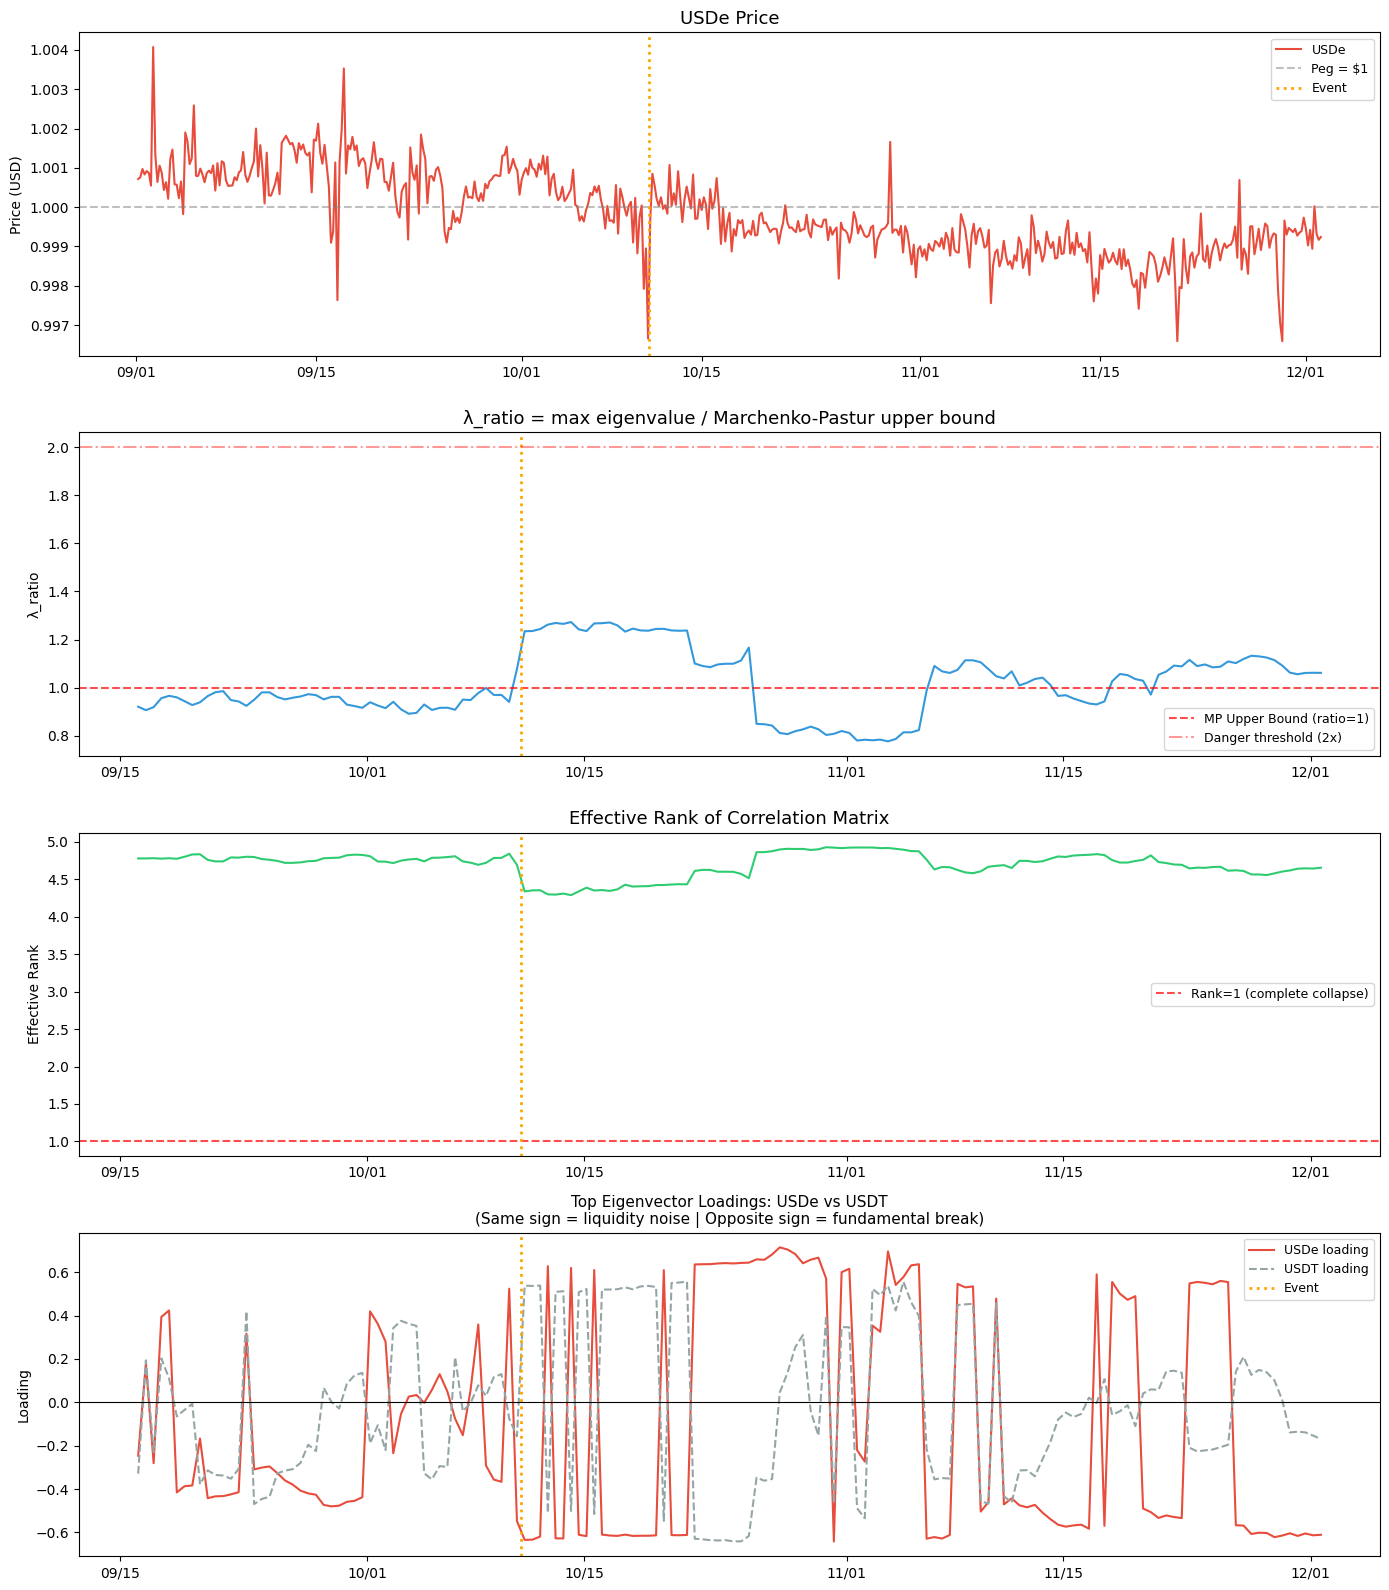

Saved: rmt_dashboard_nov.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_rmt_dashboard(prices: pd.DataFrame, rmt_results: pd.DataFrame,
                       event_date: str = "2025-10-10 21:36:00"):
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)
    event_dt = pd.Timestamp(event_date)
    
    # --- Plot 1: USDe Price ---
    ax1 = axes[0]
    ax1.plot(prices.index, prices["usde"], color="#e74c3c", linewidth=1.5, label="USDe")
    ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Peg = $1")
    ax1.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2, label="Event")
    ax1.set_title("USDe Price", fontsize=13)
    ax1.set_ylabel("Price (USD)")
    ax1.legend(fontsize=9)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    # --- Plot 2: Lambda Ratio ---
    ax2 = axes[1]
    ax2.plot(rmt_results.index, rmt_results["lambda_ratio"],
             color="#3498db", linewidth=1.5)
    ax2.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="MP Upper Bound (ratio=1)")
    ax2.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2)
    # Danger threshold (adjustable)
    ax2.axhline(y=2.0, color="red", linestyle="-.", alpha=0.4, label="Danger threshold (2x)")
    ax2.set_title("λ_ratio = max eigenvalue / Marchenko-Pastur upper bound", fontsize=13)
    ax2.set_ylabel("λ_ratio")
    ax2.legend(fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    # --- Plot 3: Effective Rank ---
    ax3 = axes[2]
    ax3.plot(rmt_results.index, rmt_results["effective_rank"],
             color="#2ecc71", linewidth=1.5)
    ax3.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="Rank=1 (complete collapse)")
    ax3.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2)
    ax3.set_title("Effective Rank of Correlation Matrix", fontsize=13)
    ax3.set_ylabel("Effective Rank")
    ax3.legend(fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    # --- Plot 4: Loadings Direction ---
    ax4 = axes[3]
    ax4.plot(rmt_results.index, rmt_results["usde_loading"],
             color="#e74c3c", linewidth=1.5, label="USDe loading")
    ax4.plot(rmt_results.index, rmt_results["usdt_loading"],
             color="#95a5a6", linewidth=1.5, linestyle="--", label="USDT loading")
    ax4.axhline(y=0, color="black", linewidth=0.8)
    ax4.axvline(x=event_dt, color="orange", linestyle=":", linewidth=2, label="Event")
    ax4.set_title("Top Eigenvector Loadings: USDe vs USDT\n"
                  "(Same sign = liquidity noise | Opposite sign = fundamental break)", fontsize=11)
    ax4.set_ylabel("Loading")
    ax4.legend(fontsize=9)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    
    plt.tight_layout()
    plt.savefig("rmt_dashboard_nov.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: rmt_dashboard_nov.png")


plot_rmt_dashboard(prices, rmt_results, event_date="2025-10-10 21:36:00")